# Modelovanie CDI

Notebook je rozdelený na logické fázy:
1. Importy a konfigurácia
2. Utility funkcie (čistenie, split, drop missing, imputácia, metriky)
3. Príprava dát 
4. Výber labov (train-only štatistiky) + Skóre_final
5. Tréning + kalibrácia + threshold
6. Vyhodnotenie a výber top modelov
7. Export bundlov pre aplikáciu

In [ ]:
import os, json, warnings
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, train_test_split, RandomizedSearchCV
from sklearn.metrics import (
    average_precision_score, roc_auc_score,
    precision_score, recall_score, f1_score,
    confusion_matrix, brier_score_loss,
    precision_recall_curve, roc_curve
)
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer, KNNImputer

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN

from xgboost import XGBClassifier

import joblib
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
RANDOM_STATE = 42

## Nastavenie dát a ciest
- `TARGET` je binárny cieľ.
- `OUT_DIR` je výstup pre modely a reporty.

In [ ]:
TARGET = "A04_7"

DATA_DIR = Path("data")        
OUT_DIR  = Path("models_2")    
OUT_DIR.mkdir(parents=True, exist_ok=True)

DATASETS = {
    "20_KNN":  "cdi_base_clean.csv",
    "20_MICE": "cdi_base_clean.csv",
}

MISSING_THRESHOLD = 0.20
TOP_N_STATS = 15
MIN_RECALL = 0.60

def imputation_from_ds_key(ds_key: str) -> str:
    ds_key = ds_key.upper()
    if "KNN" in ds_key:
        return "KNN"
    if "MICE" in ds_key:
        return "MICE"
    raise ValueError(f"Neviem určiť imputáciu z ds_key: {ds_key}")

def load_dataset(path: Path) -> pd.DataFrame:
    return pd.read_csv(path, sep=";", low_memory=False)

## Zoznamy premenných

In [ ]:
base_vars = ["Vek", "Dĺžka hospitalizácie"]

comorbid_cols = [
    "Hypertenzia",
    "Diabetes mellitus",
    "Kardiovaskulárne ochorenia",
    "Chronické respiračné ochorenia",
    "Renálne ochorenia",
    "Pečeňové ochorenia",
    "Onkologické ochorenia",
    "Imunosupresia",
]

drug_groups = {
    "Antivirotiká": [
        "MD652 | FABIFLU TABLETS", "5042D | VEKLURY", "9547D | PAXLOVID", "LAGEVRIO"
    ],
    "Imuno- (tlmenie reakcie)": [
        "02963 | PREDNISON 20 LÉČIVA", "00269 | PREDNISON 5 LÉČIVA", "84090 | DEXAMED 6",
        "1275C | DEXAMETAZÓN KRKA", "MD661 BIODEXONE-DEXAMETHASONE", "2410B HYDROCORTISONE",
        "RoActemra"
    ],
    "Imuno+ (stimulácia)": [
        "87299 | IMUNOR", "56930 IMMODIN", 
    ],
    "Antibiotiká": [
        "9819A MOXIFLOXACIN", "58746 CIPROFLOXACINKABI 400"
    ],
    "Iné (PPI)": [
        "05044 OZZION", "4147C OMEMYL", "89662 NOLPAZA", "39397 PANTOPRAZOL",
        "62916 SMECTA", "30639 REASEC", "84370 LAGOSA", "93105 DEGAN "
    ],
    "Kašeľ": [
        "24859 PENTOXYPHILLINUM", "8893 ACC INJEKT",
        "24949 CODEIN ", "26846 OXANTIL"
    ],
    "Antikoagulanciá": [
        "FRAXIPARIN", "FRAGMIN"
    ]
}

drug_cols = [d for g in drug_groups.values() for d in g]

LAB_COLS_ALL = [
    "S-Bil-T first","S-Bil-T last","S-Bil-T min","S-Bil-T max",
    "S-AST first","S-AST last","S-AST min","S-AST max",
    "S-ALT first","S-ALT last","S-ALT min","S-ALT max",
    "S-GMT first","S-GMT last","S-GMT min","S-GMT max",
    "S-ALP first","S-ALP last","S-ALP min","S-ALP max",
    "S-Na first","S-Na last","S-Na min","S-Na max",
    "S-K first","S-K last","S-K min","S-K max",
    "S-CL first","S-CL last","S-CL min","S-CL max",
    "S-CRP first","S-CRP last","S-CRP min","S-CRP max",
    "S-Alb first","S-Alb last","S-Alb min","S-Alb max",
    "S-Gluk first","S-Gluk last","S-Gluk min","S-Gluk max",
    "S-Urea first","S-Urea last","S-Urea min","S-Urea max",
    "S-Kreat first","S-Kreat last","S-Kreat min","S-Kreat max",
    "S-CK first","S-CK last","S-CK min","S-CK max",
    "S-CK-MB first","S-CK-MB last","S-CK-MB min","S-CK-MB max",
    "P-Laktát first","P-Laktát last","P-Laktát min","P-Laktát max",
    "S-FER first","S-FER last","S-FER min","S-FER max",
    "S-IL6 first","S-IL6 last","S-IL6 min","S-IL6 max",
    "HGB first","HGB last","HGB min","HGB max",
    "WBC first","WBC last","WBC min","WBC max",
    "PLT first","PLT last","PLT min","PLT max",
    "Neu abs first","Neu abs last","Neu abs min","Neu abs max",
    "Eo abs first","Eo abs last","Eo abs min","Eo abs max",
    "Ly abs first","Ly abs last","Ly abs min","Ly abs max",
    "PT (INR) first","PT (INR) last","PT (INR) min","PT (INR) max",
    "APTT-R first","APTT-R last","APTT-R min","APTT-R max",
    "Fib first","Fib last","Fib min","Fib max",
    "CD3+ first","CD3+ last","CD3+ min","CD3+ max",
    "CD4+ first","CD4+ last","CD4+ min","CD4+ max",
    "CD8+ first","CD8+ last","CD8+ min","CD8+ max",
    "CD4+/CD8+ first","CD4+/CD8+ last","CD4+/CD8+ min","CD4+/CD8+ max",
    "PDW first","PDW last","PDW min","PDW max",
    "NE/LY(NLR) first","NE/LY(NLR) last","NE/LY(NLR) min","NE/LY(NLR) max",
    "D-dimér HS first","D-dimér HS last","D-dimér HS min","D-dimér HS max",
    "SatO2 %",
    "S-PBNP first","S-PBNP last","S-PBNP min","S-PBNP max",
    "S-VITD first","S-VITD last","S-VITD min","S-VITD max",
]

# čistenie názvov 
def clean_column_name(name: str) -> str:
    import unicodedata, re
    name = unicodedata.normalize("NFKD", name).encode("ascii", "ignore").decode()
    name = re.sub(r"[^A-Za-z0-9_]", "_", name)
    name = re.sub(r"_+", "_", name)
    name = name.strip("_")
    return name

def clean_dataframe_columns(df: pd.DataFrame):
    mapping = {}
    new_cols = []
    for c in df.columns:
        cc = clean_column_name(c)
        mapping[c] = cc
        new_cols.append(cc)
    df2 = df.copy()
    df2.columns = new_cols
    return df2, mapping

def clean_list(cols):
    return [clean_column_name(c) for c in cols]

BASE_VARS     = clean_list(base_vars)
COMORBID_COLS = clean_list(comorbid_cols)
DRUG_COLS     = clean_list(drug_cols)
LAB_COLS_ALL  = clean_list(LAB_COLS_ALL)

## Utility funkcie 
V tejto časti sú pomocné funkcie pre:
- `prepare_xy` (oddelenie X/y, typy, drop all-NaN)
- split na `fit / calib / test`
- drop stĺpcov podľa podielu missing (fit-only)
- imputácia (KNN alebo MICE) 

In [ ]:
def prepare_xy(df: pd.DataFrame, target: str):
    assert target in df.columns, f"Target {target} nie je v datasete."

    y = pd.to_numeric(df[target], errors="coerce").fillna(0).astype(int)
    X = df.drop(columns=[target]).copy()

    # bool -> int (aby sa to lepšie spracovávalo)
    for c in X.columns:
        if X[c].dtype == bool:
            X[c] = X[c].astype("int8")

    # drop NaN (stĺpce, ktoré sú úplne prázdné)
    all_nan = [c for c in X.columns if X[c].isna().all()]
    if all_nan:
        X = X.drop(columns=all_nan)

    meta = {"dropped_all_nan": all_nan}
    return X, y, meta


def split_train_calib_test(X, y, test_size=0.20, calib_size=0.20):
    # 1) rozdelenie na train/test
    X_train_full, X_test, y_train_full, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=RANDOM_STATE
    )
    # 2) rozdelenie train na fit/calib
    X_fit, X_cal, y_fit, y_cal = train_test_split(
        X_train_full, y_train_full, test_size=calib_size,
        stratify=y_train_full, random_state=RANDOM_STATE
    )
    return X_fit, y_fit, X_cal, y_cal, X_test, y_test


def fit_drop_cols_by_missing(X_fit: pd.DataFrame, threshold: float):
    miss = X_fit.isna().mean()
    drop_cols = miss[miss > threshold].index.tolist()
    return drop_cols


def apply_drop_cols(X: pd.DataFrame, drop_cols: list):
    return X.drop(columns=[c for c in drop_cols if c in X.columns], errors="ignore")

## Imputácia (KNN/MICE) 
- Imputer fitujeme len na numerických stĺpcoch, ktoré majú v `X_fit` NaN.
- Potom ho aplikujeme na `X_cal` a `X_test`.

In [17]:
def fit_imputer(X_fit_num: pd.DataFrame, method: str):
    if method == "KNN":
        imp = KNNImputer(n_neighbors=3, weights="uniform")
        imp.fit(X_fit_num)
        return imp

    if method == "MICE":
        min_vals = X_fit_num.min(skipna=True).to_numpy()
        max_vals = X_fit_num.max(skipna=True).to_numpy()

        min_vals = np.nan_to_num(min_vals, nan=-np.inf)
        max_vals = np.nan_to_num(max_vals, nan=np.inf)

        bad = (min_vals >= max_vals) | (~np.isfinite(min_vals)) | (~np.isfinite(max_vals))
        min_vals[bad] = -np.inf
        max_vals[bad] = np.inf

        imp = IterativeImputer(
            max_iter=20,
            random_state=RANDOM_STATE,
            imputation_order="ascending",
            initial_strategy="median",
            min_value=min_vals,
            max_value=max_vals,
        )
        imp.fit(X_fit_num)
        return imp

    raise ValueError(f"Unknown imputation method: {method}")


def apply_imputer(X: pd.DataFrame, imp, cols: list[str]):
    X2 = X.copy()
    if (imp is None) or (not cols):
        return X2
    arr = imp.transform(X2[cols])
    X2[cols] = pd.DataFrame(arr, columns=cols, index=X2.index)
    return X2

## Príprava datasetu 
Funkcia:
1) načíta CSV
2) vyčistí názvy stĺpcov (raw → clean) a uloží mapping pre audit
3) pripraví X/y
4) split na fit/cal/test
5) drop missing 
6) imputácia
Výsledok je `prepared[ds_key]`.

In [ ]:
def prepare_dataset_pack(ds_key: str, fname: str):
    df_raw = load_dataset(DATA_DIR / fname)
    df, colmap = clean_dataframe_columns(df_raw)

    with open(OUT_DIR / f"{ds_key}_column_mapping.json", "w", encoding="utf-8") as f:
        json.dump(colmap, f, ensure_ascii=False, indent=2)

    imp_method = imputation_from_ds_key(ds_key)

    X, y, meta = prepare_xy(df, TARGET)

    X_fit, y_fit, X_cal, y_cal, X_test, y_test = split_train_calib_test(
        X, y, test_size=0.20, calib_size=0.20
    )

    # drop cols podľa missing
    drop_cols = fit_drop_cols_by_missing(X_fit, threshold=MISSING_THRESHOLD)
    X_fit_d  = apply_drop_cols(X_fit, drop_cols)
    X_cal_d  = apply_drop_cols(X_cal, drop_cols)
    X_test_d = apply_drop_cols(X_test, drop_cols)

    # impute num cols
    num_cols_all  = X_fit_d.select_dtypes(include=["number"]).columns.tolist()
    num_cols_miss = [c for c in num_cols_all if X_fit_d[c].isna().any()]

    if num_cols_miss:
        imputer = fit_imputer(X_fit_d[num_cols_miss], method=imp_method)
        X_fit_i  = apply_imputer(X_fit_d,  imputer, cols=num_cols_miss)
        X_cal_i  = apply_imputer(X_cal_d,  imputer, cols=num_cols_miss)
        X_test_i = apply_imputer(X_test_d, imputer, cols=num_cols_miss)
    else:
        imputer = None
        X_fit_i, X_cal_i, X_test_i = X_fit_d, X_cal_d, X_test_d

    pack = {
        "ds_key": ds_key,
        "fname": fname,
        "imp_method": imp_method,
        "colmap": colmap,
        "meta": meta,
        "drop_cols": drop_cols,
        "num_cols_miss": num_cols_miss,
        "imputer": imputer,
        "X_fit": X_fit_i,   "y_fit": y_fit,
        "X_cal": X_cal_i,   "y_cal": y_cal,
        "X_test": X_test_i, "y_test": y_test,
    }
    return pack


prepared = {}
for ds_key, fname in DATASETS.items():
    prepared[ds_key] = prepare_dataset_pack(ds_key, fname)

for ds_key, pack in prepared.items():
    print(
        f"{ds_key}: imp={pack['imp_method']} | "
        f"X_fit={pack['X_fit'].shape} X_cal={pack['X_cal'].shape} X_test={pack['X_test'].shape} | "
        f"drop_cols={len(pack['drop_cols'])} | impute_cols={len(pack['num_cols_miss'])}"
    )

20_KNN: imp=KNN | X_fit=(2462, 210) X_cal=(616, 210) X_test=(770, 210) | drop_cols=44 | impute_cols=142
20_MICE: imp=MICE | X_fit=(2462, 210) X_cal=(616, 210) X_test=(770, 210) | drop_cols=44 | impute_cols=142


## Oversampling + modely 
V ďalšej sekcii definujeme:
- oversamplery
- modely (RF, XGB, LR, MLP)
- pipeline (over + scaler + model)
- RandomizedSearchCV (scoring = average_precision)

In [ ]:
OVERSAMPLERS = {
    "None": "passthrough",
    "ROS": RandomOverSampler(random_state=RANDOM_STATE),
    "SMOTE": SMOTE(random_state=RANDOM_STATE, k_neighbors=5),
    "ADASYN": ADASYN(random_state=RANDOM_STATE, n_neighbors=5),
}

def get_oversampler(name: str):
    return OVERSAMPLERS[name]


def build_models(y_train):
    n_pos = int((y_train == 1).sum())
    n_neg = int((y_train == 0).sum())
    spw = n_neg / max(n_pos, 1)

    return {
        "RandomForest": RandomForestClassifier(
            n_estimators=600, 
            n_jobs=-1,
            random_state=RANDOM_STATE,
            class_weight="balanced_subsample"
        ),
        "XGBoost": XGBClassifier(
            n_estimators=600,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.9,
            colsample_bytree=0.9,
            reg_lambda=1.0,
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            scale_pos_weight=spw,  
        ),
        "LogReg": LogisticRegression(
            max_iter=4000,
            solver="saga",
            class_weight=None, 
            n_jobs=-1,
            random_state=RANDOM_STATE,
        ),
        "MLP": MLPClassifier(
            max_iter=600,
            random_state=RANDOM_STATE,
            early_stopping=True,
        ),
    }


PARAM_GRIDS = {
    "RandomForest": {
        "model__n_estimators": [900, 1200, 1600],
        "model__max_depth": [4, 6, 10, 16],
        "model__min_samples_split": [10, 20, 40],
        "model__min_samples_leaf": [4, 8, 12, 20],
        "model__max_features": ["sqrt", "log2", 0.3, 0.5],
        "model__class_weight": ["balanced_subsample", "balanced", None],
        "model__ccp_alpha": [0.0, 1e-4, 3e-4, 1e-3, 3e-3],
        "model__min_impurity_decrease": [0.0, 1e-4, 3e-4, 1e-3],
    },
    "XGBoost": {
        "model__n_estimators": [300, 600, 900, 1200],
        "model__max_depth": [2, 3, 4, 5, 6],
        "model__learning_rate": [0.005, 0.01, 0.03, 0.05, 0.1],
        "model__subsample": [0.6, 0.8, 0.9, 1.0],
        "model__colsample_bytree": [0.6, 0.8, 0.9, 1.0],
        "model__reg_lambda": [0.5, 1.0, 2.0, 5.0, 10.0],
        "model__reg_alpha": [0.0, 1e-3, 1e-2, 1e-1],
        "model__min_child_weight": [1, 3, 5, 8, 12],
        "model__gamma": [0, 0.1, 0.3, 0.6, 1.0],
        "model__max_leaves": [0, 16, 32, 64],
    },
    "LogReg": {
        "model__C": [0.003, 0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0, 30.0, 100.0],
        "model__penalty": ["l1", "l2"],
        "model__tol": [1e-4, 3e-4, 1e-3],
    },
    "MLP": {
        "model__hidden_layer_sizes": [(32,), (64,), (64, 32), (128, 64)],
        "model__alpha": [1e-5, 1e-4, 1e-3],
        "model__learning_rate_init": [1e-4, 3e-4, 1e-3],
    },
}

USE_SCALER_FOR = {"LogReg", "MLP"}  # stromové modely netreba škálovať

def make_pipeline(base_model, oversampler_name: str, model_name: str):
    over = get_oversampler(oversampler_name)
    scaler = StandardScaler() if (model_name in USE_SCALER_FOR) else "passthrough"
    pipe = ImbPipeline(steps=[
        ("over", over),
        ("scale", scaler),
        ("model", base_model)
    ])
    return pipe

def tune_model_cv(X_train, y_train, base_model, oversampler_name, model_name, param_grid, n_iter=30):
    pipe = make_pipeline(base_model, oversampler_name, model_name)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=param_grid,
        n_iter=n_iter,
        scoring="average_precision",  
        cv=cv,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=0,
        refit=True
    )
    search.fit(X_train, y_train)
    return search.best_estimator_, float(search.best_score_), search.best_params_

## Threshold optimalizácia, metriky a vizualizácie
- Threshold vyberáme na **calib** množine s podmienkou `Recall >= MIN_RECALL` a maximalizáciou precision (a potom recall).
- Metriky reportujeme na **test** množine.
- Pridáme základné ploty: PR, ROC, Confusion matrix.

In [20]:
def choose_threshold_min_recall(y_true, y_prob, min_recall=0.60, n_grid=2000):
    thresholds = np.linspace(0.0005, 0.9995, n_grid)
    best = None  # (thr, prec, rec, f1, pred_pos)

    for thr in thresholds:
        pred = (y_prob >= thr).astype(int)
        rec = recall_score(y_true, pred, zero_division=0)

        if rec >= min_recall:
            prec = precision_score(y_true, pred, zero_division=0)
            f1 = f1_score(y_true, pred, zero_division=0)
            pred_pos = int(pred.sum())

            if (
                (best is None)
                or (prec > best[1])
                or (prec == best[1] and rec > best[2])
                or (prec == best[1] and rec == best[2] and pred_pos < best[4])
            ):
                best = (float(thr), float(prec), float(rec), float(f1), pred_pos)

    return best


def compute_all_metrics(y_true, prob, thr):
    pred = (prob >= thr).astype(int)
    cm = confusion_matrix(y_true, pred)

    return {
        "Precision": float(precision_score(y_true, pred, zero_division=0)),
        "Recall": float(recall_score(y_true, pred, zero_division=0)),
        "F1": float(f1_score(y_true, pred, zero_division=0)),
        "PR_AUC": float(average_precision_score(y_true, prob)),
        "ROC_AUC": float(roc_auc_score(y_true, prob)),
        "Brier": float(brier_score_loss(y_true, prob)),
        "CM": cm,
        "PredPos": int(pred.sum()),
        "ShareFlagged_%": float(pred.mean() * 100.0),
    }

In [ ]:
def fit_and_calibrate(best_pipe, X_fit, y_fit, X_cal, y_cal):
    # fit pipeline na fit časti
    best_pipe.fit(X_fit, y_fit)

    # kalibrácia na calib časti 
    model_cal = CalibratedClassifierCV(
        estimator=best_pipe,
        method="sigmoid",
        cv="prefit"
    )
    model_cal.fit(X_cal, y_cal)
    return model_cal


def pick_threshold_on_calib(model_cal, X_cal, y_cal, min_recall):
    prob_cal = model_cal.predict_proba(X_cal)[:, 1]
    sel = choose_threshold_min_recall(y_cal.values, prob_cal, min_recall=min_recall)
    if sel is None:
        return 0.01

    thr, _, _, _, _ = sel   
    return float(thr)

In [22]:
def plot_pr(y_true, prob, title):
    p, r, _ = precision_recall_curve(y_true, prob)
    ap = average_precision_score(y_true, prob)
    plt.figure()
    plt.plot(r, p)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{title} | AP={ap:.4f}")
    plt.grid(True)
    plt.show()

def plot_roc(y_true, prob, title):
    fpr, tpr, _ = roc_curve(y_true, prob)
    auc = roc_auc_score(y_true, prob)
    plt.figure()
    plt.plot(fpr, tpr)
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.title(f"{title} | AUC={auc:.4f}")
    plt.grid(True)
    plt.show()

def plot_cm(cm, title):
    cm = np.array(cm)
    total = cm.sum()
    cm_pct = cm / max(total, 1) * 100.0

    plt.figure(figsize=(5.2, 4.2))
    plt.imshow(cm, cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.xticks([0, 1], ["CDI−", "CDI+"])
    plt.yticks([0, 1], ["CDI−", "CDI+"])

    for (i, j), v in np.ndenumerate(cm):
        plt.text(j, i, f"{v}\n({cm_pct[i,j]:.1f}%)", ha="center", va="center", fontsize=10)

    plt.tight_layout()
    plt.show()

## Integrácia `score_final_utils` (TOP labs + Skóre_final) 
- výpočet štatistík pre laboratorné hodnoty
- výber TOP_N_STATS labov podľa sily signálu
- fit `score_cfg` 
- pripravenie dvoch vetiev dát:
  - `use_score=False`: featury bez Skóre_final
  - `use_score=True`: najprv doplníme Skóre_final

In [23]:
from score_final_utils import (
    compute_and_save_train_lab_stats_for_dp,
    pick_top_labs_by_stats,
    build_feature_list_for_model,
    slice_X_to_features,
    apply_score_config,
    fit_score_config,
    save_features_expected,
)

DP_DIR = OUT_DIR / "dp_stats"
DP_DIR.mkdir(parents=True, exist_ok=True)

In [ ]:
SCORE_PREPARED = {}

for ds_key, pack in prepared.items():
    X_fit_base, y_fit = pack["X_fit"], pack["y_fit"]
    X_cal_base = pack["X_cal"]
    X_test_base = pack["X_test"]

    stats_tag = f"{ds_key}_{pack['imp_method']}"

    _ = compute_and_save_train_lab_stats_for_dp(
        X_fit=X_fit_base,
        y_fit=y_fit,
        lab_cols_all=LAB_COLS_ALL,
        out_dir=DP_DIR,
        tag=stats_tag,
        alpha=0.05,
        min_abs_r=0.05,
        min_non_nan=30,
        min_pos=5,
        top_k=30,
    )

    # Načítaj tabuľky
    diff_tbl = pd.read_csv(DP_DIR / f"train_mwu_all_{stats_tag}.csv")
    corr_tbl = pd.read_csv(DP_DIR / f"train_corr_all_{stats_tag}.csv")

    # TOP_N_STATS 
    top_clean, ranked = pick_top_labs_by_stats(
        diff_table=diff_tbl,
        corr_table=corr_tbl,
        top_n=TOP_N_STATS,
        alpha=0.05,
        min_abs_r=0.05,
    )

    cols_to_show = [
        c for c in ["Name", "q_value", "mwu_strength", "abs_r", "corr_strength", "strength"]
        if c in ranked.columns
    ]
    print(top_clean[:30])
    print(ranked.head(30)[cols_to_show])

    final_labs_clean = list(top_clean)

    ranked_out = DP_DIR / f"ranked_strength_{stats_tag}.csv"
    ranked.to_csv(ranked_out, index=False, encoding="utf-8")

    # overlap report (pre text DP)
    print("\n" + "=" * 90)
    print(f"{ds_key} | imp={pack['imp_method']}")
    print("=" * 90)
    print(f"TOP{TOP_N_STATS}={len(top_clean)} | FINAL_LABS={len(final_labs_clean)}")
    print("Saved ranked:", ranked_out)

    # fit score_cfg 
    score_cfg = fit_score_config(
        X_fit=X_fit_base.copy(),
        y_fit=y_fit,
        core_labs=final_labs_clean,
        base_vars=BASE_VARS,
        lab_cols_all=None,
        do_lab_selection=False,
        comorbid_cols=COMORBID_COLS,
        drug_cols=DRUG_COLS,
        exclude_from_score=set(),
        min_non_nan=30,
        min_unique=5,
        min_pos=5,
    )

    # featury pre modelovanie
    features_no_score = build_feature_list_for_model(
        final_labs_clean=final_labs_clean,
        base_vars=BASE_VARS,
        comorbid_cols=COMORBID_COLS,
        drug_cols=DRUG_COLS,
        include_score=False,
    )
    features_with_score = build_feature_list_for_model(
        final_labs_clean=final_labs_clean,
        base_vars=BASE_VARS,
        comorbid_cols=[],
        drug_cols=[],
        include_score=True,
    )

    # vetva bez score: len orež
    X_fit_ns  = slice_X_to_features(X_fit_base,  features_no_score,  tag=f"{ds_key}|noscore|fit")
    X_cal_ns  = slice_X_to_features(X_cal_base,  features_no_score,  tag=f"{ds_key}|noscore|cal")
    X_test_ns = slice_X_to_features(X_test_base, features_no_score,  tag=f"{ds_key}|noscore|test")

    # LIME background = celé X_fit po orezaní na featury modelu (bez score vetva)
    lime_df_ref_ns = X_fit_ns.copy()

    SCORE_PREPARED[(ds_key, False)] = {
        "X_fit": X_fit_ns, "X_cal": X_cal_ns, "X_test": X_test_ns,
        "score_cfg": None,
        "lime_df_ref": lime_df_ref_ns,
        "final_labs_clean": final_labs_clean,
        "top_clean": top_clean,
        "lab_rules_n": 0,
        "features_used": features_no_score,
        "stats_tag": stats_tag,
        "ranked_path": str(ranked_out),
    }

    # vetva so score: doplň Skore_final, potom zrež
    X_fit_sc  = apply_score_config(X_fit_base.copy(), score_cfg)
    X_cal_sc  = apply_score_config(X_cal_base.copy(), score_cfg)
    X_test_sc = apply_score_config(X_test_base.copy(), score_cfg)

    X_fit_sc2  = slice_X_to_features(X_fit_sc,  features_with_score, tag=f"{ds_key}|score|fit")
    X_cal_sc2  = slice_X_to_features(X_cal_sc,  features_with_score, tag=f"{ds_key}|score|cal")
    X_test_sc2 = slice_X_to_features(X_test_sc, features_with_score, tag=f"{ds_key}|score|test")

    # LIME background = celé X_fit po score + orezaní na featury modelu (score vetva)
    lime_df_ref_sc = X_fit_sc2.copy()

    lab_rules_n = int(len(score_cfg.get("lab_rules", [])))
    bin_risk_n = int(len(score_cfg.get("binary_risk_cols", [])))

    SCORE_PREPARED[(ds_key, True)] = {
        "X_fit": X_fit_sc2, "X_cal": X_cal_sc2, "X_test": X_test_sc2,
        "score_cfg": score_cfg,
        "lime_df_ref": lime_df_ref_sc,
        "final_labs_clean": final_labs_clean,
        "top_clean": top_clean,
        "lab_rules_n": lab_rules_n,
        "binary_risk_n": bin_risk_n,
        "features_used": features_with_score,
        "stats_tag": stats_tag,
        "ranked_path": str(ranked_out),
    }

    print(
        f"[{ds_key}] FINAL_LABS={len(final_labs_clean)} | "
        f"n_features(no_score)={X_fit_ns.shape[1]} | n_features(score)={X_fit_sc2.shape[1]} | "
        f"lab_rules={lab_rules_n} | binary_risk={bin_risk_n}"
    )


TRAIN LAB STATS (DP) | 20_KNN_KNN
labs_present=141 | selected=57
Saved: models_2\dp_stats\train_lab_stats_report_20_KNN_KNN.txt
Saved: models_2\dp_stats\train_mwu_all_20_KNN_KNN.csv
Saved: models_2\dp_stats\train_corr_all_20_KNN_KNN.csv
['S_CRP_last', 'Neu_abs_max', 'S_IL6_last', 'NE_LY_NLR_max', 'WBC_max', 'S_K_min', 'S_CRP_max', 'D_dimer_HS_max', 'S_IL6_max', 'S_AST_min', 'Ly_abs_min', 'S_IL6_min', 'NE_LY_NLR_last', 'HGB_min', 'PDW_max']
               Name  mwu_strength  corr_strength  strength
0        S_CRP_last      7.381646       1.615813  8.997460
1       Neu_abs_max      7.381646       0.699407  8.081053
2        S_IL6_last      7.649051       0.000000  7.649051
3     NE_LY_NLR_max      6.067480       1.238962  7.306442
4           WBC_max      6.908695       0.288994  7.197689
5           S_K_min      5.793825       0.783728  6.577553
6         S_CRP_max      5.105612       0.469180  5.574792
7    D_dimer_HS_max      4.738059       0.149042  4.887101
8         S_IL6_max     

## Hlavný cyklus
Pre každú kombináciu:
- dataset (KNN/MICE),
- `use_score` (False/True),
- oversampling,
- model

spravíme:
1) RandomizedSearchCV na fit 
2) kalibráciu na calib i
3) výber threshold na calib (min recall)
4) test metriky na test
5) uloženie `expected_features.json` pre appku
6) uloženie `artifacts` (model_cal, thr, a aj X_test/y_test pre ploty)

In [ ]:
results_rows = []
artifacts = {}

OVERSAMPLING_LIST = ["None", "ROS", "SMOTE", "ADASYN"]
USE_SCORE_LIST = [False, True]

for ds_key, pack in prepared.items():
    y_fit  = pack["y_fit"]
    y_cal  = pack["y_cal"]
    y_test = pack["y_test"]

    models = build_models(y_fit)

    for use_score in USE_SCORE_LIST:
        X_fit  = SCORE_PREPARED[(ds_key, use_score)]["X_fit"].copy()
        X_cal  = SCORE_PREPARED[(ds_key, use_score)]["X_cal"].copy()
        X_test = SCORE_PREPARED[(ds_key, use_score)]["X_test"].copy()

        final_labs_n = len(SCORE_PREPARED[(ds_key, use_score)]["final_labs_clean"])
        lab_rules_n  = SCORE_PREPARED[(ds_key, use_score)]["lab_rules_n"]

        for over_name in OVERSAMPLING_LIST:
            for model_name, base_model in models.items():

                print(
                    f"{ds_key} | imp={pack['imp_method']} | score={use_score} | "
                    f"final_labs={final_labs_n} | rules={lab_rules_n} | "
                    f"n_features={X_fit.shape[1]} | model={model_name} | over={over_name}"
                )

                best_pipe, cv_ap, best_params = tune_model_cv(
                    X_fit, y_fit,
                    base_model=base_model,
                    oversampler_name=over_name,
                    model_name=model_name,
                    param_grid=PARAM_GRIDS[model_name],
                    n_iter=30
                )

                model_cal = fit_and_calibrate(best_pipe, X_fit, y_fit, X_cal, y_cal)
                thr = pick_threshold_on_calib(model_cal, X_cal, y_cal, min_recall=MIN_RECALL)

                prob_test = model_cal.predict_proba(X_test)[:, 1]
                m_test = compute_all_metrics(y_test.values, prob_test, thr)

                results_rows.append({
                    "Dataset": ds_key,
                    "Imputacia": pack["imp_method"],
                    "Use_ScoreFinal": use_score,
                    "FinalLabs_n": int(final_labs_n),
                    "LabRules_n": int(lab_rules_n),
                    "N_features": int(X_fit.shape[1]),
                    "Oversampling": over_name,
                    "Model": model_name,
                    "CV_PR_AUC": float(cv_ap),
                    "Thr": float(thr),
                    "PR_AUC": m_test["PR_AUC"],
                    "ROC_AUC": m_test["ROC_AUC"],
                    "Brier": m_test["Brier"],
                    "Precision": m_test["Precision"],
                    "Recall": m_test["Recall"],
                    "F1": m_test["F1"],
                    "PredPos": m_test["PredPos"],
                    "ShareFlagged_%": m_test["ShareFlagged_%"],
                    "RecallOK": bool(m_test["Recall"] >= MIN_RECALL),
                    "DroppedColsMissing>20%": int(len(pack["drop_cols"])),
                    "N_test": int(len(y_test)),
                    "N_pos_test": int((y_test == 1).sum()),
                    "BestParams": best_params,
                })

                expected = list(X_fit.columns)
                score_tag = f"score{int(use_score)}"
                base = clean_column_name(f"{ds_key}_{model_name}_{score_tag}_{over_name}")
                feat_path = save_features_expected(OUT_DIR, base, expected)

                key = (ds_key, use_score, over_name, model_name)
                artifacts[key] = {
                    "model_cal": model_cal,
                    "threshold": float(thr),
                    "colmap": pack["colmap"],
                    "feature_names": expected,
                    "features_path": str(feat_path),

                    "X_test": X_test,
                    "y_test": y_test,

                    "extra": {
                        "imp_method": pack["imp_method"],
                        "drop_cols": pack["drop_cols"],
                        "imputer": pack["imputer"],
                        "num_cols_miss": pack["num_cols_miss"],
                        "final_labs_clean": SCORE_PREPARED[(ds_key, use_score)]["final_labs_clean"],
                        "lab_rules_n": lab_rules_n,
                        "score_cfg": SCORE_PREPARED[(ds_key, use_score)]["score_cfg"],
                        "lime_df_ref": SCORE_PREPARED[(ds_key, use_score)]["lime_df_ref"],
                    },
                }

results_df = (
    pd.DataFrame(results_rows)
    .sort_values(["RecallOK", "PR_AUC", "Precision", "Recall"],
                 ascending=[False, False, False, False])
    .reset_index(drop=True)
)
results_df.head(30)

20_KNN | imp=KNN | score=False | final_labs=15 | rules=0 | n_features=54 | model=RandomForest | over=None
20_KNN | imp=KNN | score=False | final_labs=15 | rules=0 | n_features=54 | model=XGBoost | over=None
20_KNN | imp=KNN | score=False | final_labs=15 | rules=0 | n_features=54 | model=LogReg | over=None
20_KNN | imp=KNN | score=False | final_labs=15 | rules=0 | n_features=54 | model=MLP | over=None
20_KNN | imp=KNN | score=False | final_labs=15 | rules=0 | n_features=54 | model=RandomForest | over=ROS
20_KNN | imp=KNN | score=False | final_labs=15 | rules=0 | n_features=54 | model=XGBoost | over=ROS
20_KNN | imp=KNN | score=False | final_labs=15 | rules=0 | n_features=54 | model=LogReg | over=ROS
20_KNN | imp=KNN | score=False | final_labs=15 | rules=0 | n_features=54 | model=MLP | over=ROS
20_KNN | imp=KNN | score=False | final_labs=15 | rules=0 | n_features=54 | model=RandomForest | over=SMOTE
20_KNN | imp=KNN | score=False | final_labs=15 | rules=0 | n_features=54 | model=XGBoost 

,Dataset,Imputacia,Use_ScoreFinal,FinalLabs_n,LabRules_n,N_features,Oversampling,Model,CV_PR_AUC,Thr,...,Precision,Recall,F1,PredPos,ShareFlagged_%,RecallOK,DroppedColsMissing>20%,N_test,N_pos_test,BestParams
0,20_KNN,KNN,False,15,0,54,None,XGBoost,0.215810,0.023988,...,0.087838,0.619048,0.153846,148,19.220779,True,44,770,21,"{'model__subsample': 0.6, 'model__reg_lambda':..."
1,20_KNN,KNN,False,15,0,54,ROS,XGBoost,0.227837,0.019490,...,0.061404,0.666667,0.112450,228,29.610390,True,44,770,21,"{'model__subsample': 0.8, 'model__reg_lambda':..."
2,20_KNN,KNN,False,15,0,54,ROS,MLP,0.183095,0.013993,...,0.041322,0.714286,0.078125,363,47.142857,True,44,770,21,"{'model__learning_rate_init': 0.0001, 'model__..."
3,20_MICE,MICE,True,15,17,18,ROS,MLP,0.286761,0.025487,...,0.069519,0.619048,0.125000,187,24.285714,True,44,770,21,"{'model__learning_rate_init': 0.0003, 'model__..."
4,20_MICE,MICE,True,15,17,18,SMOTE,MLP,0.270416,0.022989,...,0.062762,0.714286,0.115385,239,31.038961,True,44,770,21,"{'model__learning_rate_init': 0.0003, 'model__..."
5,20_MICE,MICE,False,15,0,54,None,RandomForest,0.255474,0.036482,...,0.090909,0.666667,0.160000,154,20.000000,True,44,770,21,"{'model__n_estimators': 900, 'model__min_sampl..."
6,20_KNN,KNN,True,15,17,18,None,LogReg,0.273171,0.033983,...,0.078313,0.619048,0.139037,166,21.558442,True,44,770,21,"{'model__tol': 0.0003, 'model__penalty': 'l1',..."
7,20_KNN,KNN,True,15,17,18,ROS,LogReg,0.245949,0.031984,...,0.074713,0.619048,0.133333,174,22.597403,True,44,770,21,"{'model__tol': 0.0001, 'model__penalty': 'l1',..."
8,20_MICE,MICE,True,15,17,18,ADASYN,XGBoost,0.178491,0.019490,...,0.088757,0.714286,0.157895,169,21.948052,True,44,770,21,"{'model__subsample': 0.6, 'model__reg_lambda':..."
9,20_MICE,MICE,False,15,0,54,ADASYN,MLP,0.154817,0.000500,...,0.027273,1.000000,0.053097,770,100.000000,True,44,770,21,"{'model__learning_rate_init': 0.001, 'model__h..."


## Výber najlepších modelov pre jednotlivé algoritmy

In [ ]:
ALGO_LIST = ["RandomForest", "XGBoost", "LogReg", "MLP"]

best_rows = []
for algo in ALGO_LIST:
    sub = results_df[results_df["Model"] == algo].copy()

    
    sub_ok = sub[sub["RecallOK"] == True]
    if not sub_ok.empty:
        sub = sub_ok

    sub = sub.sort_values(
        ["Precision", "Recall", "F1", "PR_AUC"],
        ascending=[False, False, False, False]
    )
    best_rows.append(sub.iloc[0])

best_per_algo = pd.DataFrame(best_rows).reset_index(drop=True)
best_per_algo

,Dataset,Imputacia,Use_ScoreFinal,FinalLabs_n,LabRules_n,N_features,Oversampling,Model,CV_PR_AUC,Thr,...,Precision,Recall,F1,PredPos,ShareFlagged_%,RecallOK,DroppedColsMissing>20%,N_test,N_pos_test,BestParams
0,20_MICE,MICE,False,15,0,54,None,RandomForest,0.255474,0.036482,...,0.090909,0.666667,0.160000,154,20.000000,True,44,770,21,"{'model__n_estimators': 900, 'model__min_sampl..."
1,20_MICE,MICE,True,15,17,18,ADASYN,XGBoost,0.178491,0.019490,...,0.088757,0.714286,0.157895,169,21.948052,True,44,770,21,"{'model__subsample': 0.6, 'model__reg_lambda':..."
2,20_KNN,KNN,True,15,17,18,None,LogReg,0.273171,0.033983,...,0.078313,0.619048,0.139037,166,21.558442,True,44,770,21,"{'model__tol': 0.0003, 'model__penalty': 'l1',..."
3,20_MICE,MICE,True,15,17,18,ROS,MLP,0.286761,0.025487,...,0.069519,0.619048,0.125000,187,24.285714,True,44,770,21,"{'model__learning_rate_init': 0.0003, 'model__..."


## Zobrazenie grafov, pre najlepšie modely

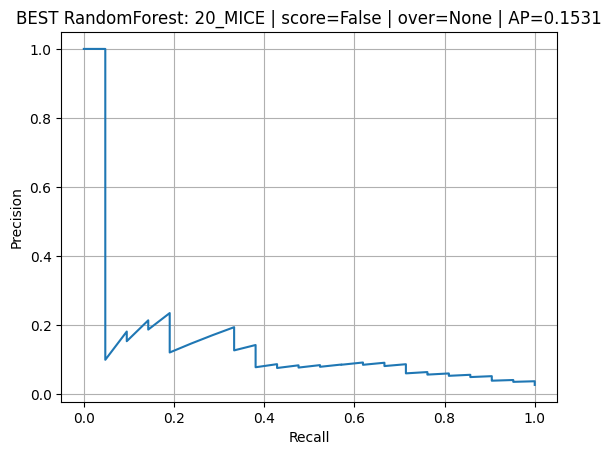

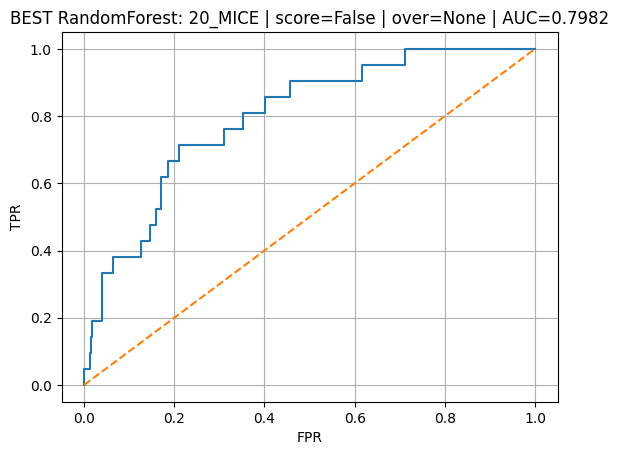

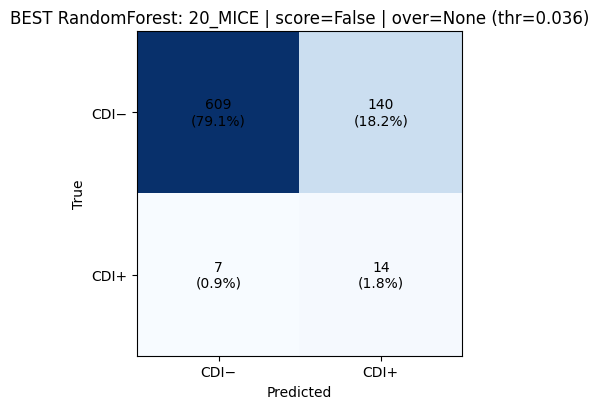

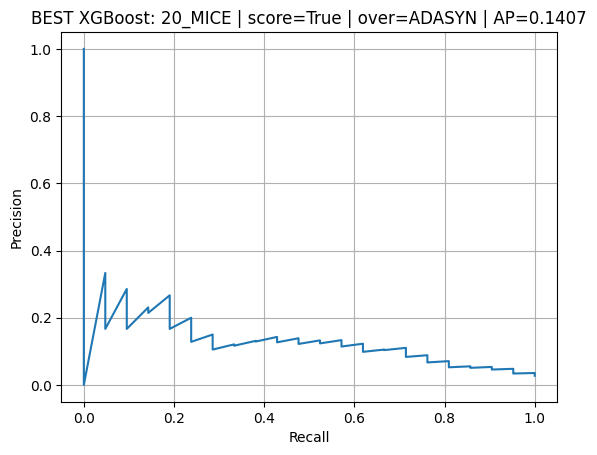

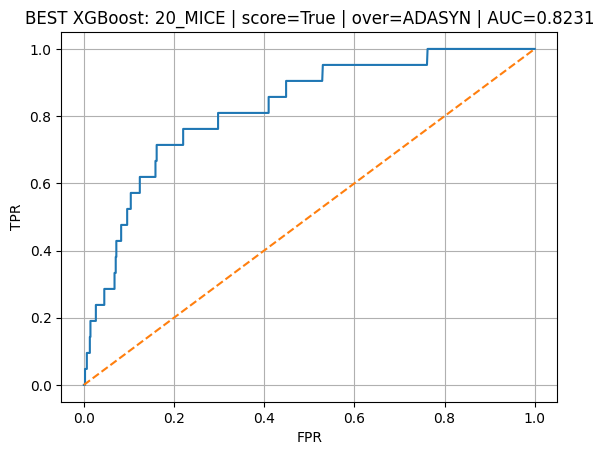

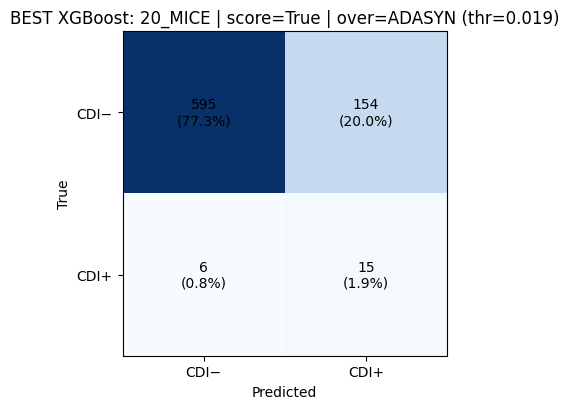

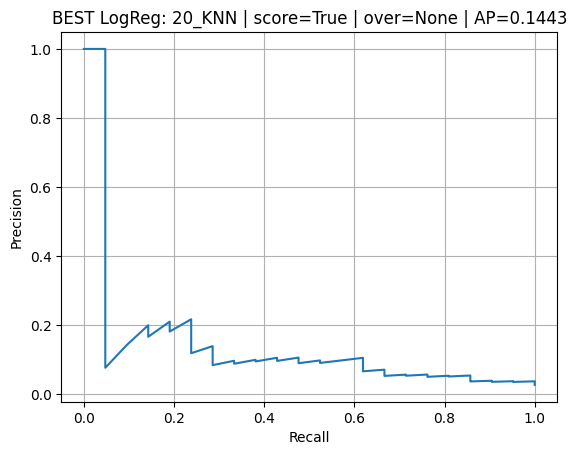

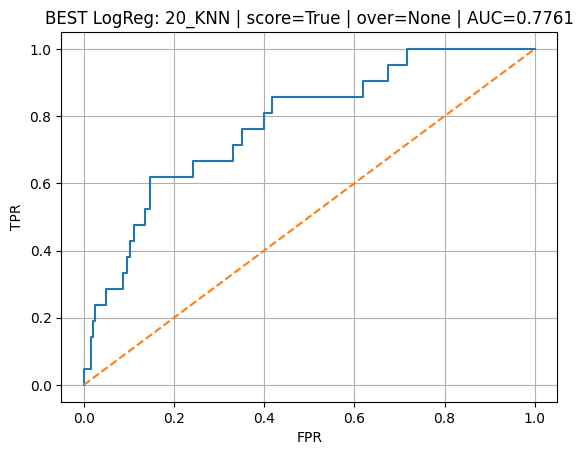

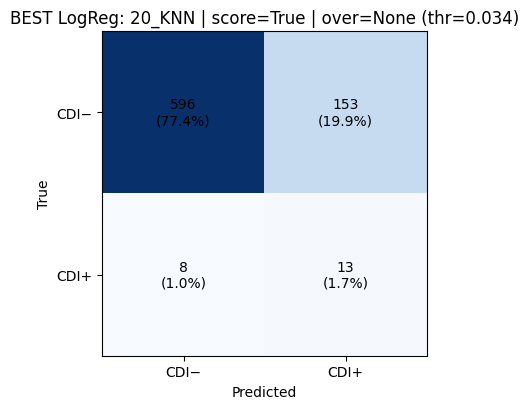

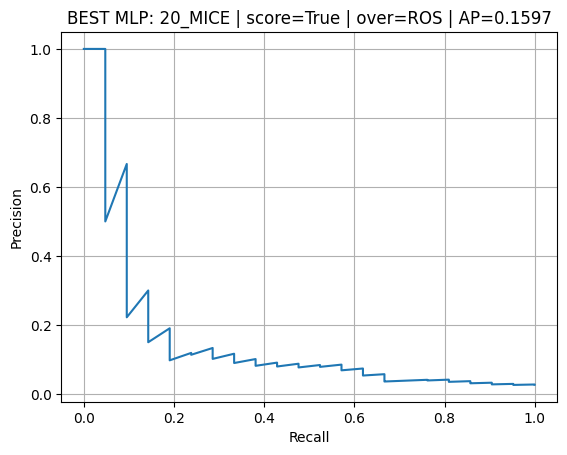

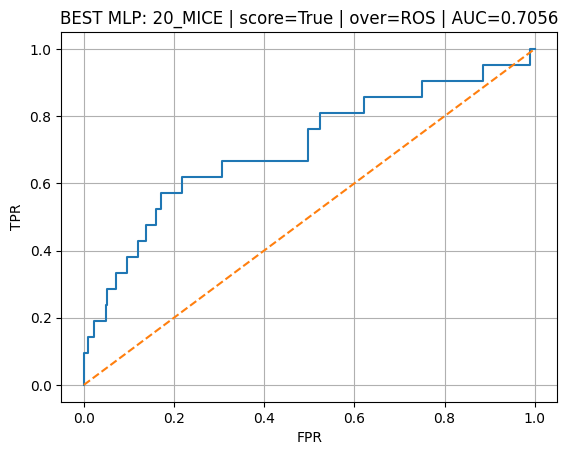

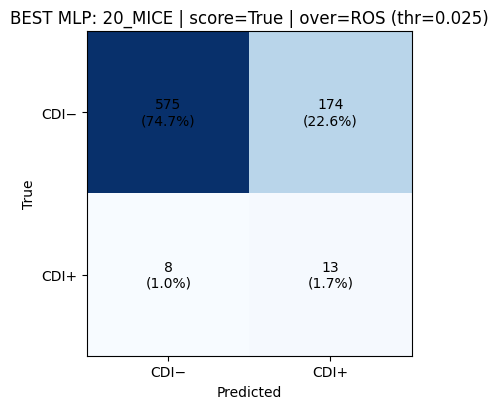

In [27]:
top3 = best_per_algo.copy()

for i, r in top3.iterrows():
    key = (r["Dataset"], r["Use_ScoreFinal"], r["Oversampling"], r["Model"])
    art = artifacts[key]
    model_cal = art["model_cal"]
    thr = art["threshold"]

    X_test = art["X_test"]
    y_test = art["y_test"]

    prob = model_cal.predict_proba(X_test)[:, 1]
    cm = confusion_matrix(y_test.values, (prob >= thr).astype(int))

    title = f"BEST {r['Model']}: {r['Dataset']} | score={r['Use_ScoreFinal']} | over={r['Oversampling']}"
    plot_pr(y_test.values, prob, title)
    plot_roc(y_test.values, prob, title)
    plot_cm(cm, title + f" (thr={thr:.3f})")

## Export bundlov pre aplikáciu
- `*.joblib` : kalibrovaný model
- `*_threshold.json` : prah rozhodnutia
- `*_features.json` : poradie stĺpcov, ktoré model očakáva 
- `*_colmap.json` : raw→clean mapping
- `*_preprocess.json` : drop_cols, imp_method, num_cols_miss, use_score, lab_rules_n, bin_risk_n...
- `*_imputer.joblib` : objekt imputera 
- `*_score_cfg.json` : konfigurácia Skore_final
- `*_lime_df_ref.joblib` : referenčný dataset pre LIME vysvetlenia


In [28]:
def json_safe(obj):
    import numpy as np
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, (np.ndarray,)):
        return obj.tolist()
    return obj

def dump_json(path: Path, payload: dict):
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(payload, f, ensure_ascii=False, indent=2, default=json_safe)

In [ ]:
def save_model_bundle(
    out_dir: Path,
    ds_key: str,
    use_score: bool,
    over_name: str,
    model_name: str,
    model_cal,
    threshold: float,
    colmap: dict,
    expected_features: list[str],
    drop_cols: list[str],
    imp_method: str,
    num_cols_miss: list[str],
    imputer_obj,
    final_labs_clean: list[str],
    lab_rules_n: int,
    score_cfg: dict | None,
    lime_df_ref=None,             
    bin_risk_n: int = 0,          
):
    score_tag = f"score{int(use_score)}"
    base = clean_column_name(f"{ds_key}_{model_name}_{score_tag}_{over_name}")

    model_path = out_dir / f"{base}.joblib"
    thr_path   = out_dir / f"{base}_threshold.json"
    map_path   = out_dir / f"{base}_colmap.json"
    feat_path  = out_dir / f"{base}_features.json"
    prep_path  = out_dir / f"{base}_preprocess.json"
    imp_path   = out_dir / f"{base}_imputer.joblib"
    score_path = out_dir / f"{base}_score_cfg.json"
    lime_path  = out_dir / f"{base}_lime_df_ref.joblib"   

    # 1) model
    joblib.dump(model_cal, model_path)

    # 2) threshold
    dump_json(thr_path, {"threshold": float(threshold)})

    # 3) colmap
    dump_json(map_path, colmap)

    # 4) expected features (poradie stĺpcov)
    dump_json(feat_path, {"expected": list(expected_features)})

    # 5) preprocess meta
    preprocess_payload = {
        "ds_key": ds_key,
        "model": model_name,
        "oversampling": over_name,
        "use_score_final": bool(use_score),

        "imp_method": imp_method,
        "num_cols_imputed": len(num_cols_miss),
        "cols_imputed": list(num_cols_miss),

        "drop_cols_missing_gt_thr": list(drop_cols),
        "n_drop_cols_missing_gt_thr": int(len(drop_cols)),

        "final_labs_clean": list(final_labs_clean),
        "final_labs_n": int(len(final_labs_clean)),
        "lab_rules_n": int(lab_rules_n),
        "bin_risk_n": int(bin_risk_n),   
    }
    dump_json(prep_path, preprocess_payload)

    # 6) imputer 
    if imputer_obj is not None:
        joblib.dump(imputer_obj, imp_path)

    # 7) score_cfg 
    if score_cfg is not None:
        dump_json(score_path, score_cfg)

    # 8) LIME background 
    if lime_df_ref is not None:
        joblib.dump(lime_df_ref, lime_path)

    print(f"Uložený bundle: {base}")
    print(f" - model:      {model_path}")
    print(f" - threshold:  {thr_path}")
    print(f" - features:   {feat_path}")
    print(f" - colmap:     {map_path}")
    print(f" - preprocess: {prep_path}")
    if imputer_obj is not None:
        print(f" - imputer:    {imp_path}")
    if score_cfg is not None:
        print(f" - score_cfg:  {score_path}")
    if lime_df_ref is not None:
        print(f" - lime_df_ref:{lime_path}")

## Uloženie TOP3 (best_per_algo) ako bundly
Použijeme `artifacts` a k nemu uložené `extra`.

In [ ]:
for _, r in top3.iterrows():
    key = (r["Dataset"], r["Use_ScoreFinal"], r["Oversampling"], r["Model"])
    art = artifacts[key]

    extra = art.get("extra", {})
    lime_df_ref = extra.get("lime_df_ref")
    imp_method    = extra.get("imp_method")
    drop_cols     = extra.get("drop_cols", [])
    score_cfg     = extra.get("score_cfg")         
    imputer_obj   = extra.get("imputer")
    num_cols_miss = extra.get("num_cols_miss", [])
    final_labs_clean = extra.get("final_labs_clean", [])
    lab_rules_n   = int(extra.get("lab_rules_n", 0))

    expected_features = art["feature_names"]

    # použitie score cfg len ak model reálne očakáva Skore_final
    score_key = clean_column_name("Skore_final")
    use_score = bool(r["Use_ScoreFinal"]) and (score_key in expected_features)
    bin_risk_n = int(len((score_cfg or {}).get("binary_risk_cols", [])))

    save_model_bundle(
        out_dir=OUT_DIR,
        ds_key=r["Dataset"],
        use_score=use_score,
        over_name=r["Oversampling"],
        model_name=r["Model"],
        model_cal=art["model_cal"],
        threshold=art["threshold"],
        colmap=art["colmap"],
        expected_features=expected_features,
        drop_cols=drop_cols,
        imp_method=imp_method,
        num_cols_miss=num_cols_miss,
        imputer_obj=imputer_obj,
        final_labs_clean=final_labs_clean,
        lab_rules_n=lab_rules_n,
        lime_df_ref=lime_df_ref, 
        bin_risk_n=bin_risk_n,

        score_cfg=score_cfg if use_score else None,
    )

    print(
        f"[SAVED] {r['Dataset']} | model={r['Model']} | over={r['Oversampling']} | "
        f"use_score={use_score} | lab_rules={lab_rules_n} | bin_risk={bin_risk_n} | "
        f"n_features={len(expected_features)}"
    )

Uložený bundle: 20_MICE_RandomForest_score0_None
 - model:      models_2\20_MICE_RandomForest_score0_None.joblib
 - threshold:  models_2\20_MICE_RandomForest_score0_None_threshold.json
 - features:   models_2\20_MICE_RandomForest_score0_None_features.json
 - colmap:     models_2\20_MICE_RandomForest_score0_None_colmap.json
 - preprocess: models_2\20_MICE_RandomForest_score0_None_preprocess.json
 - imputer:    models_2\20_MICE_RandomForest_score0_None_imputer.joblib
 - lime_df_ref:models_2\20_MICE_RandomForest_score0_None_lime_df_ref.joblib
[SAVED] 20_MICE | model=RandomForest | over=None | use_score=False | lab_rules=0 | bin_risk=0 | n_features=54
Uložený bundle: 20_MICE_XGBoost_score1_ADASYN
 - model:      models_2\20_MICE_XGBoost_score1_ADASYN.joblib
 - threshold:  models_2\20_MICE_XGBoost_score1_ADASYN_threshold.json
 - features:   models_2\20_MICE_XGBoost_score1_ADASYN_features.json
 - colmap:     models_2\20_MICE_XGBoost_score1_ADASYN_colmap.json
 - preprocess: models_2\20_MICE_XG

## Uloženie výsledkov do CSV
- `results_df` obsahuje všetky kombinácie.
- `best_per_algo` a `top3` sú finálne vybrané modely.

In [31]:
results_path = OUT_DIR / "results_all_grid_60.csv"
best_path    = OUT_DIR / "results_best_per_algo_60.csv"
top3_path    = OUT_DIR / "results_top3_60.csv"

results_df.to_csv(results_path, index=False, encoding="utf-8")
best_per_algo.to_csv(best_path, index=False, encoding="utf-8")
top3.to_csv(top3_path, index=False, encoding="utf-8")

print("Saved:")
print(" -", results_path)
print(" -", best_path)
print(" -", top3_path)

Saved:
 - models_2\results_all_grid_60.csv
 - models_2\results_best_per_algo_60.csv
 - models_2\results_top3_60.csv
